## This is a simple NPS analysis for the last 5 days of feedback on the AI-Recruiter platform.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Create a dataframe with NPS data for the last 5 days
nps_data = {
    'Metric': ['Sum of Ratings (Last 5 Days)', 'Number of Interview responses (Last 5 Days)','Total Number of Interviews (Last 5 Days)', 'NPS (Last 5 Days)'],
    'Value': [3397, 793, 1246, 4.2837]
}

nps_df = pd.DataFrame(nps_data)

# Display the dataframe
print("NPS Analysis for the Last 5 Days:")
display(nps_df)

# Optional: Format the dataframe for better display
pd.set_option('display.float_format', '{:.4f}'.format)


NPS Analysis for the Last 5 Days:


,Metric,Value
0,Sum of Ratings (Last 5 Days),3397.0000
1,Number of Interview responses (Last 5 Days),793.0000
2,Total Number of Interviews (Last 5 Days),1246.0000
3,NPS (Last 5 Days),4.2837


,Metric,Value
0,NPS Score,4.2837
1,Min Bound,3.0899
2,Max Bound,4.5441
3,Margin of Error,0.7271


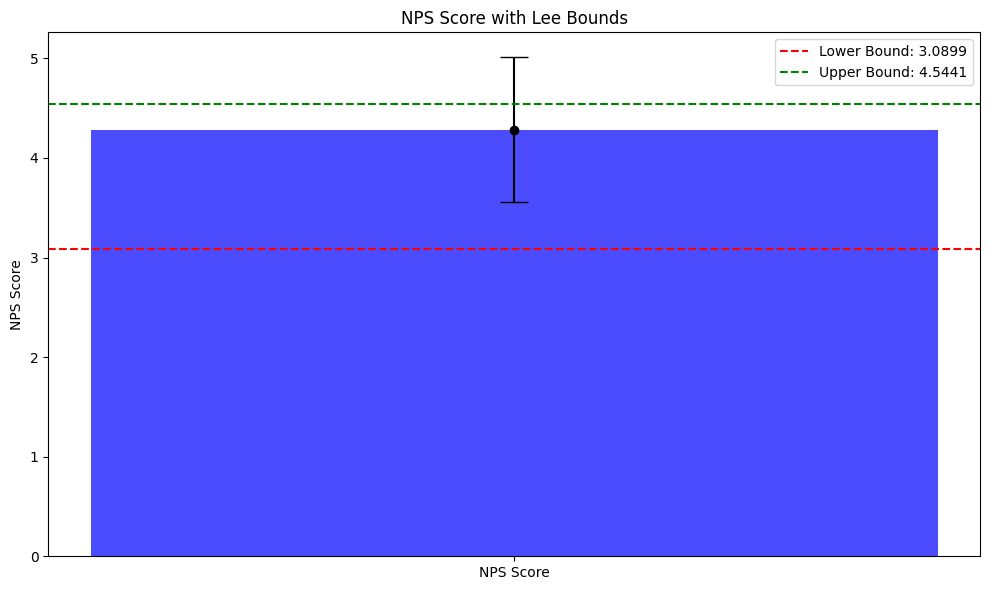

In [4]:
# Calculate Lee bounds for NPS data
# Extract values from the dataframe
sum_ratings = nps_df.loc[nps_df['Metric'] == 'Sum of Ratings (Last 5 Days)', 'Value'].values[0]
num_responses = nps_df.loc[nps_df['Metric'] == 'Number of Interview responses (Last 5 Days)', 'Value'].values[0]
total_interviews = nps_df.loc[nps_df['Metric'] == 'Total Number of Interviews (Last 5 Days)', 'Value'].values[0]
nps_score = nps_df.loc[nps_df['Metric'] == 'NPS (Last 5 Days)', 'Value'].values[0]

# Calculate missing responses
missing_responses = total_interviews - num_responses

# Calculate Lee bounds (using min_rating=1 and max_rating=5)
min_rating = 1
max_rating = 5

# NPS observed is already calculated
nps_observed = nps_score

# Calculate upper and lower bounds
nps_upper = (sum_ratings + (missing_responses * max_rating)) / total_interviews
nps_lower = (sum_ratings + (missing_responses * min_rating)) / total_interviews

# Calculate margin of error (half the width of the confidence interval)
margin_of_error = (nps_upper - nps_lower) / 2

# Create a summary DataFrame
lee_bounds_summary = pd.DataFrame({
    'Metric': ['NPS Score', 'Min Bound', 'Max Bound', 'Margin of Error'],
    'Value': [nps_observed, nps_lower, nps_upper, margin_of_error]
})

# Display the Lee bounds summary
display(lee_bounds_summary)

# Create a visualization
plt.figure(figsize=(10, 6))
plt.bar(['NPS Score'], [nps_observed], color='blue', alpha=0.7)
plt.errorbar(['NPS Score'], [nps_observed], yerr=margin_of_error, fmt='o', color='black', capsize=10)
plt.axhline(y=nps_lower, color='red', linestyle='--', label=f'Lower Bound: {nps_lower:.4f}')
plt.axhline(y=nps_upper, color='green', linestyle='--', label=f'Upper Bound: {nps_upper:.4f}')
plt.ylabel('NPS Score')
plt.title('NPS Score with Lee Bounds')
plt.legend()
plt.tight_layout()
plt.show()
